# **Semantic Analysis of Amazon Food Reviews**

## Import requisite libraries
- Review `README.md` for setup instructions.

In [1]:
from __future__ import annotations
import re
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

DATASET_CSV_PATH = (
    "/Users/advaychandramouli/dev/projects/amazon-food-reviews/data/Reviews.csv"
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {"figure.figsize": (10, 5), "axes.titlesize": 14, "axes.labelsize": 12}
)

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print(
    "Kernel note: make sure this notebook kernel is using the 'amazon-food-reviews' conda environment "
    "(e.g., via Jupyter kernel selection)."
)

_NLTK_RESOURCES: dict[str, str] = {
    "corpora/stopwords": "stopwords",
    "tokenizers/punkt": "punkt",
    "tokenizers/punkt_tab": "punkt_tab",
    "corpora/wordnet": "wordnet",
    "corpora/omw-1.4": "omw-1.4",
}

for resource_path, resource_name in _NLTK_RESOURCES.items():
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(resource_name, quiet=True)

_STOPWORDS = set(stopwords.words("english"))
_LEMMATIZER = WordNetLemmatizer()

Python: 3.14.4
Executable: /opt/homebrew/anaconda3/envs/amazon-food-reviews/bin/python
Platform: macOS-26.4.1-arm64-arm-64bit-Mach-O
Kernel note: make sure this notebook kernel is using the 'amazon-food-reviews' conda environment (e.g., via Jupyter kernel selection).


## Load Dataset
Load the CSV into a DataFrame and sanity-check schema, nulls, and duplicates.

In [2]:
from pathlib import Path

csv_path = Path(DATASET_CSV_PATH)
if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found at: {csv_path.resolve()}")

df = pd.read_csv(csv_path, low_memory=False)

print("Shape:", df.shape)
print("\nColumns:")
display(pd.Index(df.columns))

print("\nDtypes:")
display(df.dtypes)

print("\nPreview:")
display(df.head())

print("\nMissing values (top 20):")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(20))

n_duplicates = int(df.duplicated().sum())
print("\nDuplicate rows:", n_duplicates)

required_columns = {
    "Score",
    "Time",
    "HelpfulnessNumerator",
    "HelpfulnessDenominator",
    "Text",
}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise KeyError(
        "Missing required columns for this notebook: "
        f"{missing_required}. Available columns include: {sorted(df.columns)[:30]} ..."
    )

Shape: (568454, 10)

Columns:


Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time',
       'Summary', 'Text'],
      dtype='str')


Dtypes:


Id                        int64
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int64
HelpfulnessDenominator    int64
Score                     int64
Time                      int64
Summary                     str
Text                        str
dtype: object


Preview:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The fl...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."



Missing values (top 20):


Summary                   27
ProfileName               26
Id                         0
ProductId                  0
UserId                     0
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Text                       0
dtype: int64


Duplicate rows: 0


## Exploratory Data Analysis

### A) Review score distribution
Plot how often each rating (1–5) appears.

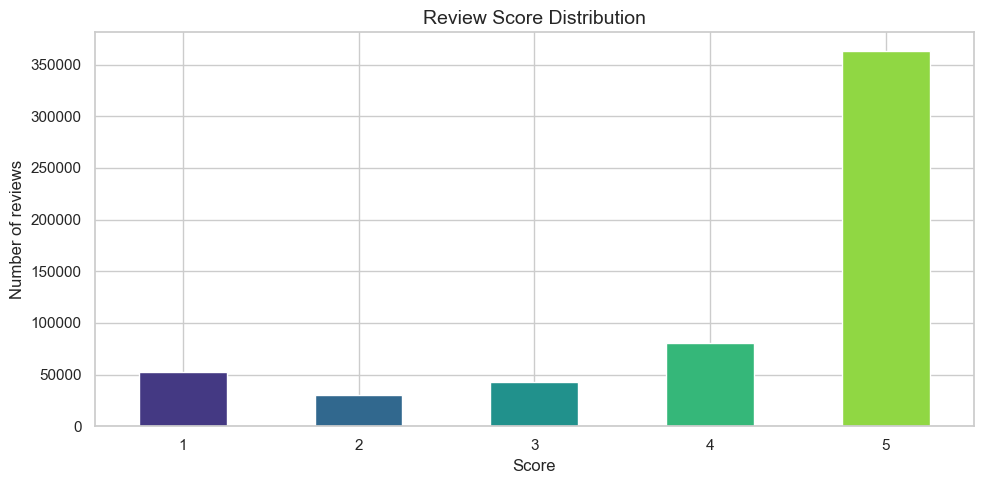

In [3]:
score_counts = (
    df["Score"]
    .dropna()
    .astype(int, errors="ignore")
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

ax = score_counts.plot(kind="bar", color=sns.color_palette("viridis", n_colors=5))
ax.set_title("Review Score Distribution")
ax.set_xlabel("Score")
ax.set_ylabel("Number of reviews")
ax.set_xticklabels([str(i) for i in score_counts.index], rotation=0)
plt.tight_layout()
plt.show()

### B) Reviews over time
Convert the Unix timestamp to datetime, extract year, count reviews per year, and plot the trend.

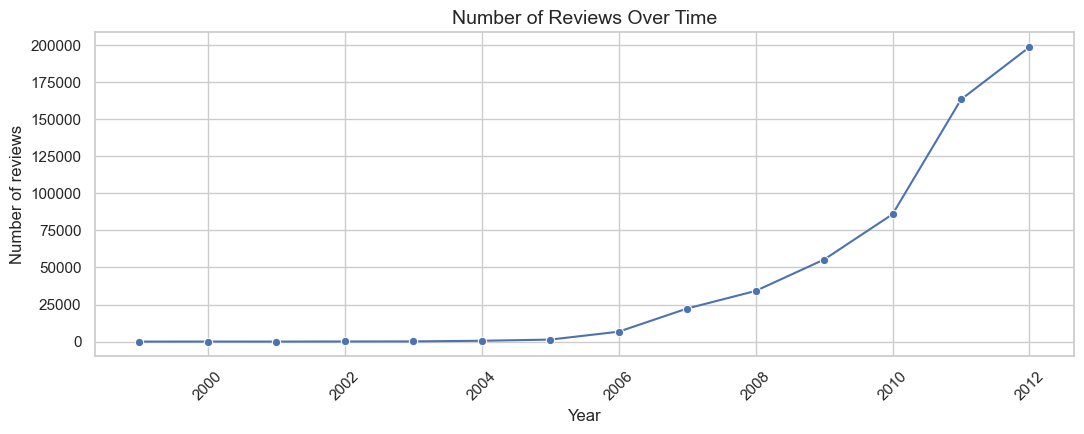

,review_count
year,
1999,6
2000,32
2001,13
2002,73
2003,132
2004,561
2005,1335
2006,6671
2007,22300


In [4]:
# Step 1: Convert integer to datetime
# The dataset's `Time` column is a Unix timestamp (seconds).
df["review_datetime"] = pd.to_datetime(df["Time"], unit="s", errors="coerce")

# Step 2: Extract year
df["year"] = df["review_datetime"].dt.year

# Step 3: Count occurrences
reviews_per_year = df["year"].value_counts(dropna=True).sort_index()

# Step 4: Plot results
plt.figure(figsize=(11, 4.5))
ax = sns.lineplot(
    x=reviews_per_year.index.astype(int), y=reviews_per_year.values, marker="o"
)
ax.set_title("Number of Reviews Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(reviews_per_year.to_frame(name="review_count").head(10))

#### C) Helpfulness ratio vs review text length
Added feature called `helpfulness_ratio` and `text_length`, to then visualize their relationship.

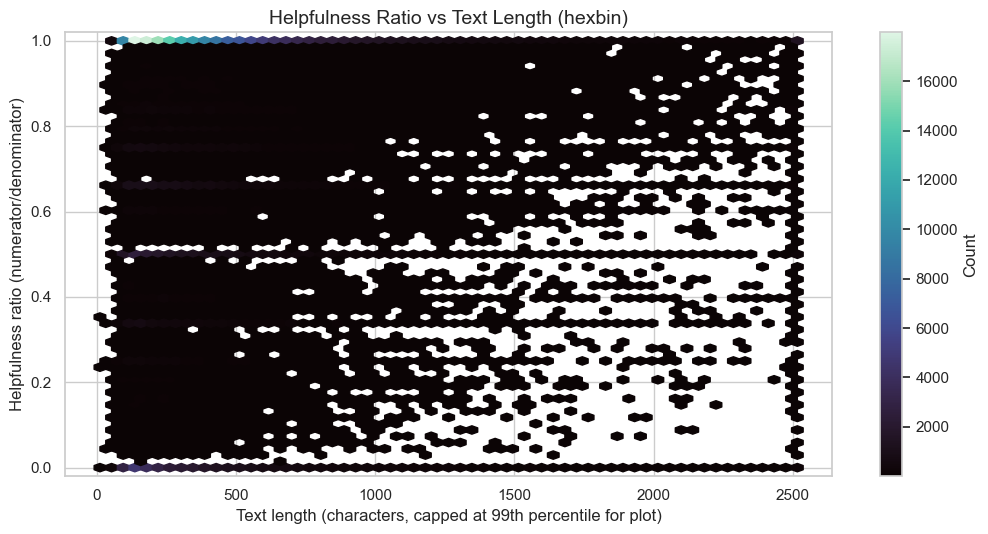

In [5]:
hn = pd.to_numeric(df["HelpfulnessNumerator"], errors="coerce")
hd = pd.to_numeric(df["HelpfulnessDenominator"], errors="coerce")

df["helpfulness_ratio"] = np.where(hd > 0, hn / hd, np.nan)


def _safe_text(s: object) -> str:
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    return str(s)


text_series = df["Text"].map(_safe_text)
df["text_length"] = text_series.str.len()

valid = df[["helpfulness_ratio", "text_length"]].dropna()

# Reduce extreme outliers for visualization only (keeps full features in the dataframe).
x = valid["text_length"].clip(upper=valid["text_length"].quantile(0.99))
y = valid["helpfulness_ratio"].clip(lower=0, upper=1)

plt.figure(figsize=(10.5, 5.5))
if len(valid) > 120_000:
    hb = plt.hexbin(x, y, gridsize=60, cmap="mako", mincnt=1)
    plt.colorbar(hb, label="Count")
    plt.title("Helpfulness Ratio vs Text Length (hexbin)")
else:
    plt.scatter(x, y, s=8, alpha=0.15, edgecolors="none")
    plt.title("Helpfulness Ratio vs Text Length")

plt.xlabel("Text length (characters, capped at 99th percentile for plot)")
plt.ylabel("Helpfulness ratio (numerator/denominator)")
plt.ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

#### Feature summary stats
Validate updated feature set

In [6]:
n_den_zero = int((hd.fillna(0) == 0).sum())
n_text_missing = int((text_series == "").sum())

print("Denominator == 0 (or missing):", n_den_zero)
print("Missing/empty Text:", n_text_missing)

display(
    df[["helpfulness_ratio", "text_length"]]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)

# Helpful sanity-check: ratio should mostly be in [0, 1] when defined.
ratio_defined = df["helpfulness_ratio"].dropna()
print(
    "\nHelpfulness ratio outside [0, 1]:",
    int(((ratio_defined < 0) | (ratio_defined > 1)).sum()),
)

Denominator == 0 (or missing): 270052
Missing/empty Text: 0


,count,mean,std,min,50%,75%,90%,95%,99%,max
helpfulness_ratio,298402.0,0.776975,0.346321,0.0,1.0,1.0,1.0,1.0,1.0,3.0
text_length,568454.0,436.222083,445.339741,12.0,302.0,527.0,877.0,1202.0,2166.0,21409.0



Helpfulness ratio outside [0, 1]: 2


## Preprocessing
Normalize review text into a `cleaned_text` column by tokenizing, removing stopwords, lemmatization and concatenation into normalized string

In [7]:
_ALPHA_RE = re.compile(r"^[a-z]+$")


def preprocess_text(text: object) -> str:
    """Clean and normalize raw review text.

    Steps:
    - lowercase
    - tokenize
    - remove punctuation / non-alphabetic tokens
    - remove stopwords
    - lemmatize
    - rejoin into a single normalized string
    """

    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""

    s = str(text).strip().lower()
    if not s:
        return ""

    tokens = word_tokenize(s)
    cleaned: list[str] = []
    for tok in tokens:
        tok = tok.strip()
        if not tok:
            continue
        if not _ALPHA_RE.match(tok):
            continue
        if tok in _STOPWORDS:
            continue
        lemma = _LEMMATIZER.lemmatize(tok)
        if lemma and lemma not in _STOPWORDS:
            cleaned.append(lemma)
    return " ".join(cleaned)


df["cleaned_text"] = df["Text"].apply(preprocess_text)

### Encode Sentiment Labels from Review Scores
Create a 3-class sentiment label from the existing `Score` column without modifying the original values

In [ ]:
def map_sentiment(score):
    """Map numeric review score to 3-class sentiment label.

    1-2 -> negative
    3   -> neutral
    4-5 -> positive
    null -> None
    """
    if pd.isna(score):
        return None

    try:
        score_value = float(score)
    except (TypeError, ValueError):
        return None

    if 1 <= score_value <= 2:
        return "negative"
    if score_value == 3:
        return "neutral"
    if 4 <= score_value <= 5:
        return "positive"
    return None


# Keep original Score column unchanged; create a new label column.
df["sentiment_label"] = df["Score"].apply(map_sentiment)

# Optional numeric encoding for modeling.
encoding_map = {"negative": 0, "neutral": 1, "positive": 2}
df["sentiment_encoded"] = df["sentiment_label"].map(encoding_map)

print("Sentiment label counts:")
print(df["sentiment_label"].value_counts(dropna=False))

print("\nScore -> Sentiment mapping check:")
print(pd.crosstab(df["Score"], df["sentiment_label"], dropna=False))

Sentiment label counts:
sentiment_label
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64

Score -> Sentiment mapping check:
sentiment_label  negative  neutral  positive
Score                                       
1                   52268        0         0
2                   29769        0         0
3                       0    42640         0
4                       0        0     80655
5                       0        0    363122


### Post-preprocessing
Comparing cleaned text quality and compare original vs cleaned lengths

In [9]:
df["cleaned_text_length"] = df["cleaned_text"].str.len()

sample = (
    df[["Text", "cleaned_text", "text_length", "cleaned_text_length"]]
    .sample(n=5, random_state=42)
    .reset_index(drop=True)
)

display(sample)
print("Empty cleaned_text:", int((df["cleaned_text"] == "").sum()))

length_stats = df[["text_length", "cleaned_text_length"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)
display(length_stats)

,Text,cleaned_text,text_length,cleaned_text_length
0,"Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch. They're crunchy and true to the texture of the other ""real"" cookies that aren't gluten-free...",tried couple brand sandwich cooky best bunch crunchy true texture real cooky might think filling make bit sweet mean satisfied sweet tooth sooner chocolate version glutino good true chocolatey tas...,485,214
1,"My cat loves these treats. If ever I can't find her in the house, I just pop the top and she bolts out of wherever she was hiding to come get a treat. She doesn't like crunchy treats much, so thes...",cat love treat ever ca find house pop top bolt wherever hiding come get treat like crunchy treat much perfect given three flavor seems like equally tend dry time near end bottle however lid handy ...,490,242
2,A little less than I expected. It tends to have a muddy taste - not what I expected since they said it was the favorite of the company.,little less expected tends muddy taste expected since said favorite company,136,75
3,"First there was Frosted Mini-Wheats, in original size, then there was Frosted Mini-Wheats Bite Size. Well, if for some reason those were too much of a mouthful, we now have Frosted Mini-Wheats Lit...",first frosted original size frosted bite size well reason much mouthful frosted little bit yes half size bite size version particular one cinnamon roll br br nothing new table exception size unnec...,1631,903
4,"and I want to congratulate the graphic artist for putting the entire product name on such a small box. The ad men must have really thought long and hard.<br /><br />But seriously, I love the prod...",want congratulate graphic artist putting entire product name small box ad men must really thought long br br seriously love product taste refreshing thought taste pleasing aftertaste sweet goldilo...,649,379


Empty cleaned_text: 1


,text_length,cleaned_text_length
count,568454.000000,568454.000000
mean,436.222083,251.399380
std,445.339741,261.050958
min,12.000000,0.000000
50%,302.000000,173.000000
75%,527.000000,303.000000
90%,877.000000,506.000000
95%,1202.000000,693.000000
99%,2166.000000,1261.000000
max,21409.000000,13945.000000


## Sentiment Scoring, TF-IDF, and ML Models

Use preprocessed text reviews and 3-class sentiment labels to accomplish the following:
1. Score sentiment with the rule-based tools VADER and TextBlob
2. Vectorize review text with TF-IDF
3. Train and evaluate Logistic Regression and Multinomial Naive Bayes
4. Compare all four approaches side by side

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# VADER lexicon is required for SentimentIntensityAnalyzer.
try:
    nltk.data.find("sentiment/vader_lexicon")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

SENTIMENT_CLASSES = ["negative", "neutral", "positive"]
RANDOM_STATE = 42

print("Sentiment class order:", SENTIMENT_CLASSES)

Week 2 libraries loaded. Sentiment class order: ['negative', 'neutral', 'positive']


### Select Model Text and Output Features
- Prefer to use `cleaned_text` if available, else programmatically revert to original `Text` column
- Map text to output `sentiment_label` feature for downstream ML application

Modeling text column: 'cleaned_text'
Target column:        'sentiment_label'
Rows before filtering: 568,454
Rows after  filtering: 568,453


,count,share
sentiment_label,,
negative,82037,0.1443
neutral,42640,0.0750
positive,443776,0.7807


/var/folders/pp/rc9k_7c569n5f_j6y4b20p2c0000gn/T/ipykernel_3304/1066824816.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


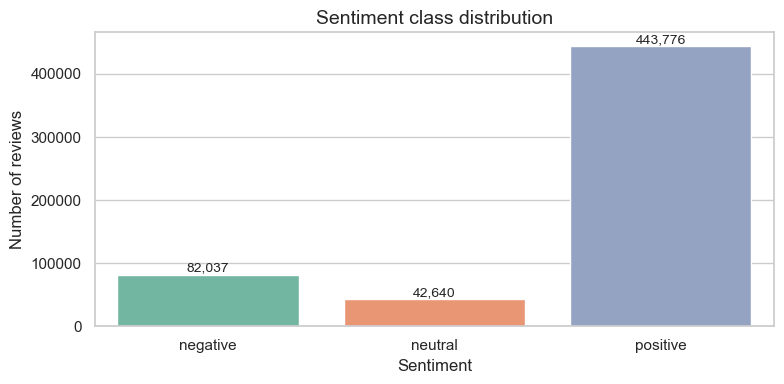

In [11]:
def pick_modeling_text_column(frame: pd.DataFrame) -> str:
    """Prefer `cleaned_text` if available and usable; otherwise fall back to `Text`."""
    if "cleaned_text" in frame.columns:
        non_empty = frame["cleaned_text"].astype("string").str.strip().ne("").sum()
        if non_empty > 0:
            return "cleaned_text"
    return "Text"


TEXT_COL = pick_modeling_text_column(df)
LABEL_COL = "sentiment_label"
print(f"Modeling text column: {TEXT_COL!r}")
print(f"Target column:        {LABEL_COL!r}")

# Work on a modeling view without mutating the original EDA dataframe.
model_df = df[[TEXT_COL, LABEL_COL]].copy()
model_df[TEXT_COL] = model_df[TEXT_COL].astype("string").fillna("").str.strip()

rows_before = len(model_df)
model_df = model_df[
    (model_df[TEXT_COL] != "") & model_df[LABEL_COL].notna()
].reset_index(drop=True)
rows_after = len(model_df)
print(f"Rows before filtering: {rows_before:,}")
print(f"Rows after  filtering: {rows_after:,}")

class_counts = model_df[LABEL_COL].value_counts().reindex(SENTIMENT_CLASSES)
class_share = (class_counts / class_counts.sum()).round(4)
class_summary = pd.DataFrame({"count": class_counts, "share": class_share})
display(class_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    order=SENTIMENT_CLASSES,
    ax=ax,
    palette="Set2",
)
ax.set_title("Sentiment class distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of reviews")
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### Helper Functions

Common helper utilites across VADER, TextBlob, and ML sections: 
- score-to-label mappers
- evaluation helper that prints accuracy, a classification report, and a confusion matrix with consistent class ordering.

In [12]:
def vader_compound_to_label(compound: float) -> str:
    """Map a VADER compound score to a 3-class sentiment label."""
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"


def textblob_polarity_to_label(polarity: float) -> str:
    """Map a TextBlob polarity score to a 3-class sentiment label."""
    if polarity > 0:
        return "positive"
    if polarity < 0:
        return "negative"
    return "neutral"


def evaluate_predictions(
    y_true,
    y_pred,
    model_name: str,
    labels: list[str] = SENTIMENT_CLASSES,
) -> dict:
    """Print accuracy + classification report and plot the confusion matrix.

    Returns a dict of summary metrics for downstream comparison.
    """
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

    print(f"=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "accuracy": acc, "macro_f1": macro_f1}

### VADER for Sentiment Scoring
- Processes each cleaned review text and generates a score
- Map `compound` score in the following interval: [-1, 1] to 3 class labels:
    - Positive: `compound >= 0.05`
    - Negative: `compound <= -0.05`
    - Neutral: if it falls between these thresholds

- Evaluate against existing labels

=== VADER (rule-based) ===
Accuracy: 0.7914
Macro F1: 0.4353

              precision    recall  f1-score   support

    negative       0.58      0.27      0.37     82037
     neutral       0.12      0.03      0.05     42640
    positive       0.82      0.96      0.89    443776

    accuracy                           0.79    568453
   macro avg       0.51      0.42      0.44    568453
weighted avg       0.73      0.79      0.75    568453



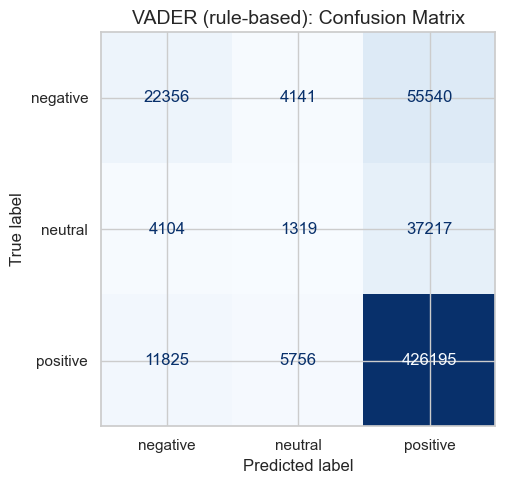

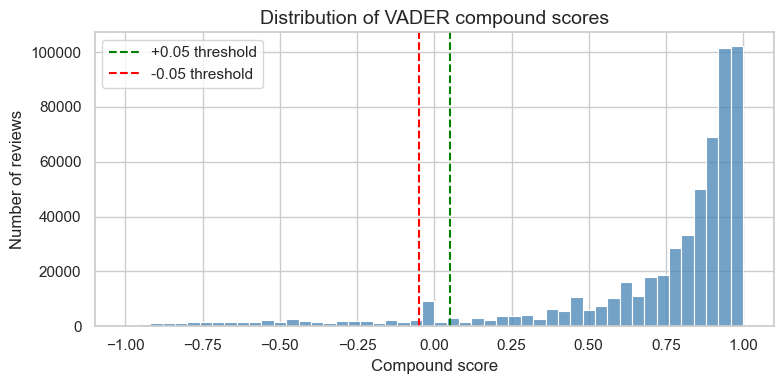

In [ ]:
vader_analyzer = SentimentIntensityAnalyzer()
def score_vader(text: str) -> float:
    return vader_analyzer.polarity_scores(text)["compound"]

# Score every review in the modeling frame and derive a 3-class prediction.
model_df["vader_compound"] = model_df[TEXT_COL].map(score_vader)
model_df["vader_pred"] = model_df["vader_compound"].map(vader_compound_to_label)

vader_metrics = evaluate_predictions(
    model_df[LABEL_COL],
    model_df["vader_pred"],
    model_name="VADER (rule-based)",
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(model_df["vader_compound"], bins=50, kde=False, ax=ax, color="steelblue")
ax.axvline(0.05, color="green", linestyle="--", label="+0.05 threshold")
ax.axvline(-0.05, color="red", linestyle="--", label="-0.05 threshold")
ax.set_title("Distribution of VADER compound scores")
ax.set_xlabel("Compound score")
ax.set_ylabel("Number of reviews")
ax.legend()
plt.tight_layout()
plt.show()

### TextBlob for Sentiment Scoring
- Processes each cleaned review text and generates a score
- Map `polarity` score in the following interval: [-1, 1] to 3 class labels:
    - Positive: `polarity > 0`
    - Negative: `polarity < 0`
    - Neutral: `polarity == 0`

- Evaluate against existing labels

=== TextBlob (rule-based) ===
Accuracy: 0.7850
Macro F1: 0.4433

              precision    recall  f1-score   support

    negative       0.51      0.35      0.42     82037
     neutral       0.09      0.02      0.03     42640
    positive       0.83      0.94      0.88    443776

    accuracy                           0.78    568453
   macro avg       0.48      0.44      0.44    568453
weighted avg       0.73      0.78      0.75    568453



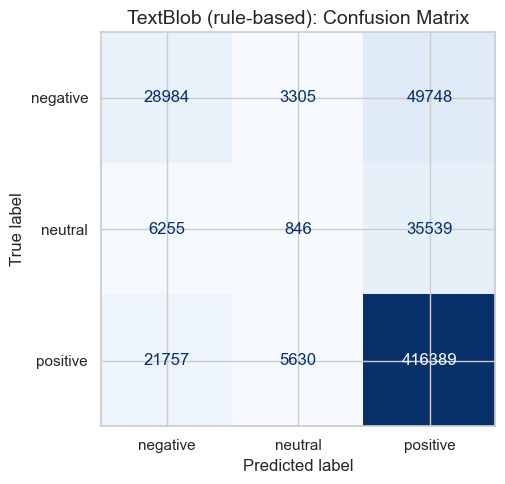

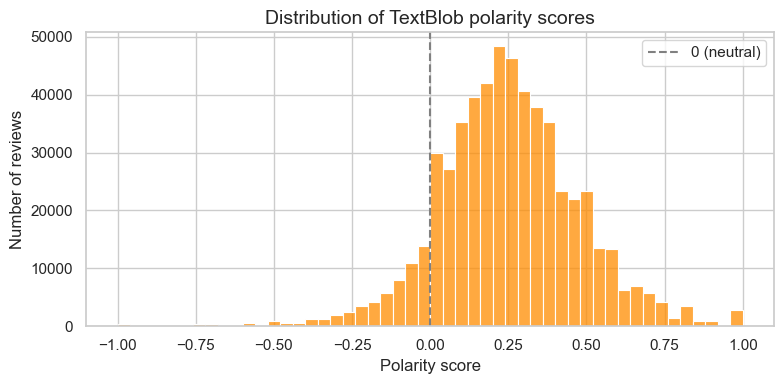

In [14]:
def score_textblob(text: str) -> float:
    return TextBlob(text).sentiment.polarity


model_df["textblob_polarity"] = model_df[TEXT_COL].map(score_textblob)
model_df["textblob_pred"] = model_df["textblob_polarity"].map(
    textblob_polarity_to_label
)

textblob_metrics = evaluate_predictions(
    model_df[LABEL_COL],
    model_df["textblob_pred"],
    model_name="TextBlob (rule-based)",
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    model_df["textblob_polarity"], bins=50, kde=False, ax=ax, color="darkorange"
)
ax.axvline(0.0, color="gray", linestyle="--", label="0 (neutral)")
ax.set_title("Distribution of TextBlob polarity scores")
ax.set_xlabel("Polarity score")
ax.set_ylabel("Number of reviews")
ax.legend()
plt.tight_layout()
plt.show()

### Feature Extraction using TF-IDF

- Extract text and target features, split data into train/test (80/20) with stratification
- Fit TF-IDF vectorizer on training text with configuration: max_features=20,000, ngram_range=(1, 2), min_df=5
- Transform both train and test sets into sparse TF-IDF matrices

In [15]:
X_text = model_df[TEXT_COL].astype(str)
y = model_df[LABEL_COL]

# Stratified split keeps the negative/neutral/positive proportions in both folds.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

# Keep track of which original rows ended up in the test set so VADER/TextBlob can
# be re-scored on the same held-out subset for a fair comparison later.
test_index = y_test.index

print(f"Train text shape: {X_train_text.shape}  ->  TF-IDF: {X_train_tfidf.shape}")
print(f"Test  text shape: {X_test_text.shape}  ->  TF-IDF: {X_test_tfidf.shape}")
print(f"Vocabulary size:  {len(tfidf_vectorizer.vocabulary_):,}")

Train text shape: (454762,)  ->  TF-IDF: (454762, 20000)
Test  text shape: (113691,)  ->  TF-IDF: (113691, 20000)
Vocabulary size:  20,000


## Machine Learning Algorithms on TF-IDF

### Logistic Regression on TF-IDF

- Linear baseline for text classification, on sparse text features created from TF-IDF

/opt/homebrew/anaconda3/envs/amazon-food-reviews/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== TF-IDF + Logistic Regression ===
Accuracy: 0.8807
Macro F1: 0.6774

              precision    recall  f1-score   support

    negative       0.77      0.72      0.74     16407
     neutral       0.61      0.24      0.35      8528
    positive       0.91      0.97      0.94     88756

    accuracy                           0.88    113691
   macro avg       0.76      0.64      0.68    113691
weighted avg       0.87      0.88      0.87    113691



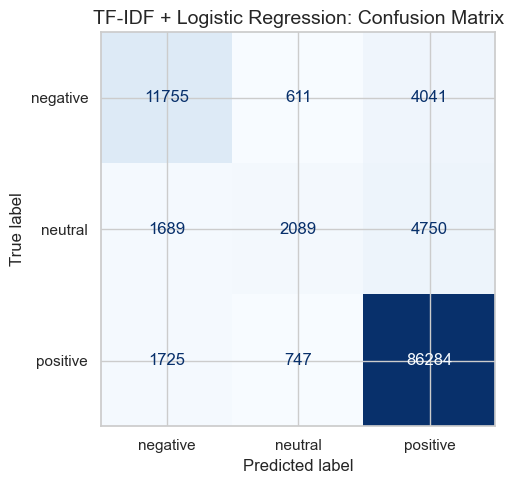

In [16]:
logreg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    solver="saga",
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_tfidf, y_train)

y_pred_logreg = logreg.predict(X_test_tfidf)
logreg_metrics = evaluate_predictions(
    y_test,
    y_pred_logreg,
    model_name="TF-IDF + Logistic Regression",
)

### Multinomial Naive Bayes on TF-IDF

- Lightweight text classifier which assumes feature independence and suited for quickly training on TF-IDF features

=== TF-IDF + Multinomial Naive Bayes ===
Accuracy: 0.8397
Macro F1: 0.5273

              precision    recall  f1-score   support

    negative       0.81      0.44      0.57     16407
     neutral       0.59      0.05      0.10      8528
    positive       0.84      0.99      0.91     88756

    accuracy                           0.84    113691
   macro avg       0.75      0.50      0.53    113691
weighted avg       0.82      0.84      0.80    113691



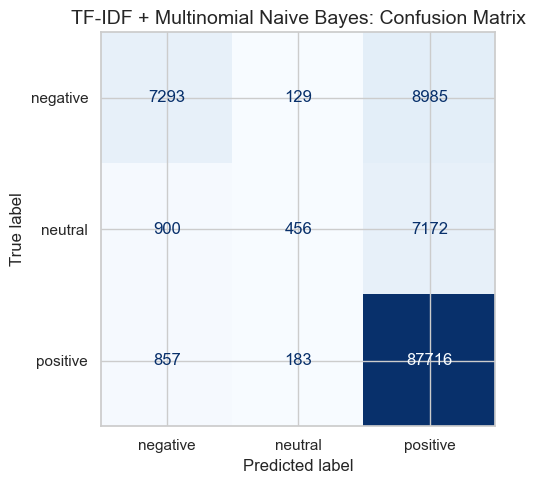

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
nb_metrics = evaluate_predictions(
    y_test,
    y_pred_nb,
    model_name="TF-IDF + Multinomial Naive Bayes",
)

### Model Evaluation
- Comparison of all 4 approaches on accuracy and F-1 score metric basis, along with some visualizations for interpretability

,accuracy,macro_f1
model,,
TF-IDF + Logistic Regression,0.8807,0.6774
TF-IDF + Multinomial NB,0.8397,0.5273
VADER,0.7913,0.4344
TextBlob,0.7857,0.4439


/var/folders/pp/rc9k_7c569n5f_j6y4b20p2c0000gn/T/ipykernel_3304/3711076717.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


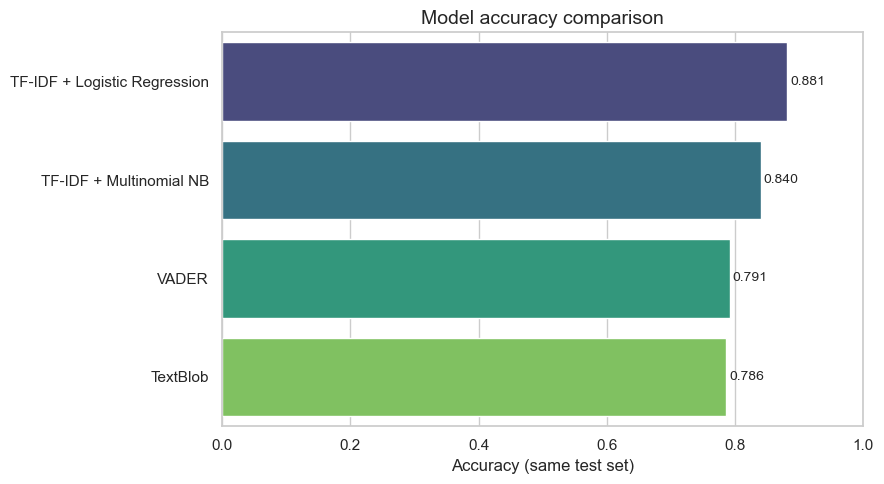

In [18]:
def summarize(y_true, y_pred, name: str) -> dict:
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true, y_pred, labels=SENTIMENT_CLASSES, average="macro", zero_division=0
        ),
    }


# Re-score VADER and TextBlob on the same test indices used by the ML models.
vader_test_pred = model_df.loc[test_index, "vader_pred"]
textblob_test_pred = model_df.loc[test_index, "textblob_pred"]

comparison_rows = [
    summarize(y_test, vader_test_pred, "VADER"),
    summarize(y_test, textblob_test_pred, "TextBlob"),
    summarize(y_test, y_pred_logreg, "TF-IDF + Logistic Regression"),
    summarize(y_test, y_pred_nb, "TF-IDF + Multinomial NB"),
]

comparison_df = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
    .round(4)
    .sort_values("accuracy", ascending=False)
)
display(comparison_df)

fig, ax = plt.subplots(figsize=(9, 5))
order = comparison_df.index.tolist()
sns.barplot(
    x=comparison_df["accuracy"].values,
    y=order,
    orient="h",
    ax=ax,
    palette="viridis",
)
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy (same test set)")
ax.set_ylabel("")
ax.set_title("Model accuracy comparison")
for i, v in enumerate(comparison_df["accuracy"].values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()